In [1]:
import pandas as pd
import sqlalchemy
import psycopg2

# --- Database Connection Details ---
# Make sure your Docker container is running!
DB_NAME = "chris_db"
DB_USER = "postgres"
DB_PASSWORD = "password"  # The password you set in your docker run command
DB_HOST = "localhost"
DB_PORT = "5432"

# Create the database connection URL
db_url = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

# Create a SQLAlchemy engine
try:
    engine = sqlalchemy.create_engine(db_url)
    print("Successfully connected to the database!")
except Exception as e:
    print(f"Failed to connect to the database. Error: {e}")


# --- Read Data from the 'binance_trades' Table ---
table_name_trades = "binance_trades"
# Corrected Query: Using 'timestamp_ms' instead of 'time'
query_trades = f"SELECT * FROM {table_name_trades} ORDER BY timestamp_ms DESC LIMIT 1000;"

try:
    with engine.connect() as connection:
        df_trades = pd.read_sql(query_trades, connection)
    
    print(f"\nSuccessfully loaded {len(df_trades)} rows from '{table_name_trades}'.")
    # In a script, you'd use print(). In a notebook, display() is prettier.
    # display(df_trades.head()) 
    print(df_trades.head())
except Exception as e:
    print(f"Failed to read data from table '{table_name_trades}'. Error: {e}")


# --- Read Data from the 'binance_orderbook_features' Table ---
table_name_ob = "binance_orderbook_features"
# Corrected Query: Using 'timestamp_ms' instead of 'time'
query_ob = f"SELECT * FROM {table_name_ob} ORDER BY timestamp_ms DESC LIMIT 1000;"

try:
    with engine.connect() as connection:
        df_orderbook = pd.read_sql(query_ob, connection)
    
    print(f"\nSuccessfully loaded {len(df_orderbook)} rows from '{table_name_ob}'.")
    # In a script, you'd use print(). In a notebook, display() is prettier.
    # display(df_orderbook.head())
    print(df_orderbook.head())
except Exception as e:
    print(f"Failed to read data from table '{table_name_ob}'. Error: {e}")


Successfully connected to the database!

Successfully loaded 1000 rows from 'binance_trades'.
    timestamp_ms  sell_volume  buy_volume  vwap_sell_price  vwap_buy_price  \
0  1750541437018        0.112       0.000         101663.7             0.0   
1  1750541436861        0.012       0.003         101663.7        101663.8   
2  1750541436730        0.054       0.020         101663.7        101663.8   
3  1750541436603        0.004       0.245         101663.7        101663.8   
4  1750541436460        0.004       0.000         101663.7             0.0   

   total_volume  total_trade_count  
0         0.112                  6  
1         0.015                  5  
2         0.074                  3  
3         0.249                  6  
4         0.004                  1  

Successfully loaded 1000 rows from 'binance_orderbook_features'.
    timestamp_ms  bid_l1_price  bid_l1_cumulative_qty  bid_l1_weighted_price  \
0  1750541437101      101663.7                 11.357               1

In [67]:
limit = 500000

In [68]:
# --- Read Data from the 'binance_trades' Table ---
table_name = "binance_trades"
query = f"SELECT * FROM {table_name} ORDER BY timestamp_ms DESC LIMIT {limit};"

try:
    with engine.connect() as connection:
        df_binance_trades = pd.read_sql(query, connection)
    
    print(f"Successfully loaded {len(df_binance_trades)} rows from '{table_name}'.")
    display(df_binance_trades.head())
except Exception as e:
    print(f"Failed to read data from table '{table_name}'. Error: {e}")

Successfully loaded 500000 rows from 'binance_trades'.


,timestamp_ms,sell_volume,buy_volume,vwap_sell_price,vwap_buy_price,total_volume,total_trade_count
0,1750542653229,0.140,0.003,101633.1,101633.2,0.143,12
1,1750542653077,0.000,0.004,0.0,101633.2,0.004,2
2,1750542652844,0.007,0.006,101633.1,101633.2,0.013,2
3,1750542652842,0.007,0.002,101633.1,101633.2,0.009,2
4,1750542652648,0.055,0.000,101633.1,0.0,0.055,3


In [69]:
# --- Read Data from the 'binance_orderbook_features' Table ---
table_name = "binance_orderbook_features"
query = f"SELECT * FROM {table_name} ORDER BY timestamp_ms DESC LIMIT {limit};"

try:
    with engine.connect() as connection:
        df_binance_ob = pd.read_sql(query, connection)
    
    print(f"Successfully loaded {len(df_binance_ob)} rows from '{table_name}'.")
    display(df_binance_ob.head())
except Exception as e:
    print(f"Failed to read data from table '{table_name}'. Error: {e}")

Successfully loaded 500000 rows from 'binance_orderbook_features'.


,timestamp_ms,bid_l1_price,bid_l1_cumulative_qty,bid_l1_weighted_price,ask_l1_price,ask_l1_cumulative_qty,ask_l1_weighted_price,bid_l5_price,bid_l5_cumulative_qty,bid_l5_weighted_price,...,bid_l10_weighted_price,ask_l10_price,ask_l10_cumulative_qty,ask_l10_weighted_price,bid_l20_price,bid_l20_cumulative_qty,bid_l20_weighted_price,ask_l20_price,ask_l20_cumulative_qty,ask_l20_weighted_price
0,1750542653340,101633.1,0.039,101633.1,101633.2,9.491,101633.2,101632.2,0.508,101632.916929,...,101632.537662,101635.1,20.514,101633.938057,101628.3,2.233,101630.548768,101636.7,20.950,101633.974134
1,1750542653213,101633.1,0.108,101633.1,101633.2,8.270,101633.2,101632.2,0.577,101632.938821,...,101632.594307,101635.1,19.293,101633.984766,101628.3,2.302,101630.625239,101636.7,19.729,101634.022044
2,1750542653077,101633.1,0.245,101633.1,101633.2,8.271,101633.2,101632.2,0.714,101632.969748,...,101632.678589,101635.1,19.347,101633.985011,101628.3,2.439,101630.764248,101636.7,19.783,101634.022181
3,1750542652842,101633.1,0.252,101633.1,101633.2,8.130,101633.2,101632.2,0.721,101632.971012,...,101632.685024,101635.1,19.494,101633.988689,101628.5,2.434,101630.540961,101636.8,19.931,101634.025709
4,1750542652648,101633.1,0.260,101633.1,101633.2,8.161,101633.2,101632.2,0.729,101632.972428,...,101632.688995,101635.1,19.526,101633.987499,101628.5,2.442,101630.549345,101636.8,19.963,101634.024485


In [70]:
# --- Read Data from the 'brti_prices' Table ---
table_name = "brti_prices"
query = f"SELECT * FROM {table_name} ORDER BY timestamp_ms DESC LIMIT {limit};"

try:
    with engine.connect() as connection:
        df_brti = pd.read_sql(query, connection)
    
    print(f"Successfully loaded {len(df_brti)} rows from '{table_name}'.")
    display(df_brti.head())
except Exception as e:
    print(f"Failed to read data from table '{table_name}'. Error: {e}")

Successfully loaded 75780 rows from 'brti_prices'.


,timestamp_ms,brti_price,simple_average
0,1750542597897,101800.53,101706.109500
1,1750542594550,101797.77,101703.652500
2,1750542591518,101796.46,101701.065833
3,1750542588658,101797.73,101698.558500
4,1750542586024,101789.52,101696.166667


In [71]:
df_brti['time_delta'] = df_brti['timestamp_ms'] - df_brti['timestamp_ms'].shift(1)

df_brti['time_delta'].describe()

count     75779.000000
mean      -1432.074704
std        3537.553387
min     -330547.000000
25%       -1070.000000
50%       -1002.000000
75%        -960.000000
max        -303.000000
Name: time_delta, dtype: float64

# cleaning brti data

In [7]:
import numpy as np

In [72]:
# find all valid sequences 

def standardize_financial_data(df):
    """
    Standardize financial data by rounding timestamps up to nearest second
    and keeping the most recent price for duplicate timestamps.
    
    Parameters:
    df: DataFrame with columns 'timestamp_ms' and 'price'
    
    Returns:
    DataFrame with standardized timestamps (every 1000ms)
    """
    # Create a copy to avoid modifying original data
    df_clean = df.copy()
    
    # Store original timestamp for tie-breaking
    df_clean['original_timestamp'] = df_clean['timestamp_ms']
    
    # Round UP to nearest 1000ms - simpler approach to avoid overflow
    df_clean['timestamp_ms'] = ((df_clean['timestamp_ms'] + 999) // 1000) * 1000
    
    # Sort by rounded timestamp, then by original timestamp (descending for most recent)
    df_clean = df_clean.sort_values(['timestamp_ms', 'original_timestamp'], 
                                   ascending=[True, False])
    
    # Keep only the first occurrence (which is the most recent due to sorting)
    df_clean = df_clean.drop_duplicates(subset=['timestamp_ms'], keep='first')
    
    # Clean up and return only the required columns
    df_result = df_clean[['timestamp_ms', 'brti_price']].reset_index(drop=True)
    
    return df_result

def find_consecutive_sequences(df):
    """
    Find all valid consecutive sequences of seconds in the standardized data.
    
    Parameters:
    df: DataFrame with standardized timestamps (every 1000ms) and prices
    
    Returns:
    List of DataFrames, each containing a consecutive sequence
    """
    # Sort by timestamp to ensure proper order
    df_sorted = df.sort_values('timestamp_ms').reset_index(drop=True)
    
    # Calculate differences between consecutive timestamps
    df_sorted['time_diff'] = df_sorted['timestamp_ms'].diff()
    
    # Mark where new sequences start (diff != 1000ms or first row)
    df_sorted['new_sequence'] = (df_sorted['time_diff'] != 1000) | (df_sorted['time_diff'].isna())
    
    # Create sequence groups
    df_sorted['sequence_id'] = df_sorted['new_sequence'].cumsum()
    
    # Split into separate sequences
    sequences = []
    for seq_id in df_sorted['sequence_id'].unique():
        sequence_df = df_sorted[df_sorted['sequence_id'] == seq_id][['timestamp_ms', 'brti_price']].copy()
        sequences.append(sequence_df.reset_index(drop=True))
    
    return sequences

def get_sequence_info(sequences):
    """
    Get information about each sequence.
    
    Parameters:
    sequences: List of DataFrames from find_consecutive_sequences
    
    Returns:
    DataFrame with sequence statistics
    """
    info = []
    for i, seq in enumerate(sequences):
        info.append({
            'sequence_id': i,
            'length': len(seq),
            'start_time': seq['timestamp_ms'].iloc[0],
            'end_time': seq['timestamp_ms'].iloc[-1],
            'duration_seconds': len(seq)
        })
    
    return pd.DataFrame(info)

def standardize_and_find_sequences(df, min_sequence_length=10):
    """
    Complete pipeline: standardize data and find consecutive sequences.
    
    Parameters:
    df: Original DataFrame with timestamp_ms and price
    min_sequence_length: Minimum length of sequences to keep
    
    Returns:
    Tuple of (all_sequences, valid_sequences, sequence_info)
    """
    # First standardize the data
    df_standardized = standardize_financial_data(df)
    
    # Find consecutive sequences
    all_sequences = find_consecutive_sequences(df_standardized)
    
    # Filter sequences by minimum length
    valid_sequences = [seq for seq in all_sequences if len(seq) >= min_sequence_length]
    
    # Get sequence information
    sequence_info = get_sequence_info(all_sequences)
    
    return all_sequences, valid_sequences, sequence_info

all_seqs, valid_seqs, info = standardize_and_find_sequences(df_brti, min_sequence_length=2)
print(f"Found {len(all_seqs)} total sequences, {len(valid_seqs)} valid sequences")
print(info)

Found 13280 total sequences, 5961 valid sequences
       sequence_id  length     start_time       end_time  duration_seconds
0                0       3  1750434077000  1750434079000                 3
1                1       3  1750434081000  1750434083000                 3
2                2       3  1750434085000  1750434087000                 3
3                3       3  1750434089000  1750434091000                 3
4                4       3  1750434093000  1750434095000                 3
...            ...     ...            ...            ...               ...
13275        13275       1  1750542587000  1750542587000                 1
13276        13276       1  1750542589000  1750542589000                 1
13277        13277       1  1750542592000  1750542592000                 1
13278        13278       1  1750542595000  1750542595000                 1
13279        13279       1  1750542598000  1750542598000                 1

[13280 rows x 5 columns]


# feature engineering on orderbook and trades

In [73]:
df_binance_ob['l1_spread'] = df_binance_ob['ask_l1_price'] - df_binance_ob['bid_l1_price']
df_binance_ob['l5_spread'] = df_binance_ob['ask_l5_price'] - df_binance_ob['bid_l5_price']
df_binance_ob['l10_spread'] = df_binance_ob['ask_l10_price'] - df_binance_ob['bid_l10_price']
df_binance_ob['l20_spread'] = df_binance_ob['ask_l20_price'] - df_binance_ob['bid_l20_price']

df_binance_ob = df_binance_ob.drop(columns=[ 
                                            'bid_l1_price', 'ask_l1_price', 
                                            'bid_l5_price', 'ask_l5_price', 
                                            'bid_l10_price', 'ask_l10_price', 
                                            'bid_l20_price', 'ask_l20_price',
                                            'bid_l1_weighted_price', 'ask_l1_weighted_price',
                                            'bid_l5_weighted_price', 'ask_l5_weighted_price',
                                            'bid_l10_weighted_price', 'ask_l10_weighted_price',
                                            'bid_l20_weighted_price', 'ask_l20_weighted_price'
                                            ])

df_binance_trades = df_binance_trades.drop(columns=['vwap_sell_price', 'vwap_buy_price'])

# standardizing binance data

In [74]:
def standardize_financial_data_100ms(df):
    """
    Standardize financial data by rounding timestamps up to nearest 100ms
    and keeping the most recent price for duplicate timestamps.
    
    Parameters:
    df: DataFrame with columns 'timestamp_ms' and 'price'
    
    Returns:
    DataFrame with standardized timestamps (every 100ms)
    """
    # Create a copy to avoid modifying original data
    df_clean = df.copy()
    
    # Store original timestamp for tie-breaking
    df_clean['original_timestamp'] = df_clean['timestamp_ms']
    
    # Round UP to nearest 100ms
    df_clean['timestamp_ms'] = ((df_clean['timestamp_ms'] + 99) // 100) * 100
    
    # Sort by rounded timestamp, then by original timestamp (descending for most recent)
    df_clean = df_clean.sort_values(['timestamp_ms', 'original_timestamp'], 
                                   ascending=[True, False])
    
    # Keep only the first occurrence (which is the most recent due to sorting)
    df_clean = df_clean.drop_duplicates(subset=['timestamp_ms'], keep='first')
    
    # Clean up and return only the required columns
    df_result = df_clean.reset_index(drop=True)
    
    return df_result

standardized_orderbook_features = standardize_financial_data_100ms(df_binance_ob)
standardized_trades = standardize_financial_data_100ms(df_binance_trades)

standardized_orderbook_features.head()

,timestamp_ms,bid_l1_cumulative_qty,ask_l1_cumulative_qty,bid_l5_cumulative_qty,ask_l5_cumulative_qty,bid_l10_cumulative_qty,ask_l10_cumulative_qty,bid_l20_cumulative_qty,ask_l20_cumulative_qty,l1_spread,l5_spread,l10_spread,l20_spread,original_timestamp
0,1750478086200,4.592,12.146,5.158,12.207,6.279,13.123,6.482,14.789,0.1,1.7,3.1,6.9,1750478086129
1,1750478086300,4.596,12.146,5.162,12.207,6.283,13.123,6.486,14.578,0.1,1.7,3.1,6.8,1750478086253
2,1750478086400,4.602,12.072,5.168,12.133,6.289,13.049,6.492,14.504,0.1,1.7,3.1,6.6,1750478086367
3,1750478086500,4.605,12.080,5.171,12.141,6.340,13.249,6.543,14.451,0.1,1.7,3.2,6.7,1750478086470
4,1750478086700,4.648,12.139,5.875,12.390,6.431,13.113,6.678,14.571,0.1,1.8,3.4,7.2,1750478086667


In [76]:
def is_consecutive_timestamps(df, interval_ms=100):
    """
    Check if a dataframe has consecutive timestamps.
    
    Parameters:
    df: DataFrame with 'timestamp_ms' column
    interval_ms: Expected interval between consecutive timestamps in milliseconds (default 100)
    
    Returns:
    bool: True if all timestamps are consecutive, False otherwise
    """
    if len(df) <= 1:
        return True  # Single row or empty dataframe is considered consecutive
    
    # Sort by timestamp to ensure proper order
    df_sorted = df.sort_values('timestamp_ms').reset_index(drop=True)
    
    # Calculate differences between consecutive timestamps
    time_diffs = df_sorted['timestamp_ms'].diff().dropna()
    
    # Check if all differences equal the expected interval
    return (time_diffs == interval_ms).all()

In [85]:
from tqdm import tqdm

samples = []

for seq in tqdm(all_seqs):

    seq['target'] = seq['brti_price'].diff()
    seq = seq.dropna()

    # now find binance orderbook and trades CENTERED on each timestamp
    for row in seq.iterrows():
        timestamp = row[1]['timestamp_ms']
        target = row[1]['target']

        threshold = 500 # within the next 500ms
        binance_ob = standardized_orderbook_features[(standardized_orderbook_features['timestamp_ms'] - timestamp <= 500) & (standardized_orderbook_features['timestamp_ms'] - timestamp >= 0)]
        binance_trades = standardized_trades[(standardized_trades['timestamp_ms'] - timestamp <= 500) & (standardized_trades['timestamp_ms'] - timestamp >= 0)]

        if len(binance_ob) == 5 and len(binance_trades) == 5:
            # orderbook_good = is_consecutive_timestamps(binance_ob)
            # trades_good = is_consecutive_timestamps(binance_trades)

            sample = {
                'timestamp': timestamp,
                'target': target,
                'orderbook': binance_ob,
                'trades': binance_trades
            }
            samples.append(sample)
            
print(len(samples))

100%|██████████| 13280/13280 [06:22<00:00, 34.72it/s]  

4452


In [86]:
def extract_features_from_sample(sample):
    orderbook = sample['orderbook']
    trades = sample['trades']
    
    # Sort by timestamp to ensure proper order
    orderbook = orderbook.sort_values('timestamp_ms').reset_index(drop=True)
    trades = trades.sort_values('timestamp_ms').reset_index(drop=True)
    
    book_features = orderbook.columns
    trade_features = trades.columns

    num_features = len(orderbook.columns) + len(trades.columns)
    
    # Create feature matrix
    sequence_length = len(orderbook)
    feature_matrix = np.zeros((sequence_length, num_features))
    
    # Fill orderbook features (first 24 columns)
    for i, feature in enumerate(book_features):
        feature_matrix[:, i] = orderbook[feature].values
    
    # Fill trades features (last 6 columns)
    for i, feature in enumerate(trade_features):
        feature_matrix[:, len(book_features) + i] = trades[feature].values
    
    return feature_matrix

In [87]:
import matplotlib.pyplot as plt

(4452, 5, 20) (4452,)


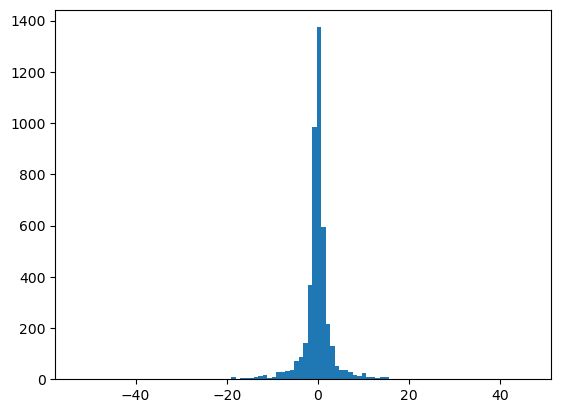

In [88]:
X = []
Y = []

for sample in samples:
    
    target = sample['target']
    orderbook = sample['orderbook']
    trades = sample['trades']   


    orderbook = orderbook.drop(columns=['timestamp_ms', 'original_timestamp'])
    trades = trades.drop(columns=['timestamp_ms', 'original_timestamp'])

    feature_matrix = extract_features_from_sample(sample)
    X.append(np.array(feature_matrix))
    Y.append(target)

X = np.array(X)
Y = np.array(Y)


print(X.shape, Y.shape)

plt.hist(Y, bins=100)
plt.show()

# 1D CNN Model

In [89]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super(ResidualBlock1D, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        # Skip connection adjustment if input/output channels differ
        self.skip_conv = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        
    def forward(self, x):
        identity = x
        
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        
        # Adjust skip connection if needed
        if self.skip_conv:
            identity = self.skip_conv(identity)
            
        out += identity
        return F.relu(out)

class BTCPricePredictorCNN(nn.Module):
    def __init__(self, input_features=20, sequence_length=3):
        super(BTCPricePredictorCNN, self).__init__()
        
        self.input_features = input_features
        self.sequence_length = sequence_length
        
        # Initial conv layer
        self.initial_conv = nn.Conv1d(input_features, 64, kernel_size=3, padding=1)
        
        # Residual blocks
        self.res_block1 = ResidualBlock1D(64, 32, kernel_size=3)
        self.res_block2 = ResidualBlock1D(32, 32, kernel_size=3)
        
        # Global average pooling (implemented as adaptive avg pool)
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        
        # Final dense layers
        self.fc1 = nn.Linear(32, 32)
        self.dropout = nn.Dropout(0.1)
        self.fc2 = nn.Linear(32, 1)
        
    def forward(self, x):
        # Input shape: (batch_size, sequence_length, input_features)
        # Conv1D expects: (batch_size, channels, sequence_length)
        x = x.transpose(1, 2)  # (batch_size, input_features, sequence_length)
        
        # Initial convolution
        x = F.relu(self.initial_conv(x))
        
        # Residual blocks
        x = self.res_block1(x)
        x = self.res_block2(x)
        
        # Global average pooling
        x = self.global_avg_pool(x)  # (batch_size, 32, 1)
        x = x.squeeze(-1)  # (batch_size, 32)
        
        # Final dense layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # (batch_size, 1)
        
        return x

class ImprovedBTCPricePredictorCNN(nn.Module):
    def __init__(self, input_features=20, sequence_length=3):
        super(ImprovedBTCPricePredictorCNN, self).__init__()
        
        self.input_features = input_features
        self.sequence_length = sequence_length
        
        # More sophisticated architecture
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(input_features, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
        )
        
        # Attention mechanism
        self.attention = nn.MultiheadAttention(64, num_heads=4, batch_first=True)
        
        # Global pooling
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # Final dense layers with better initialization
        self.fc1 = nn.Linear(64, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        
        # Initialize weights properly
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)
        
    def forward(self, x):
        # Input shape: (batch_size, sequence_length, input_features)
        # Conv1D expects: (batch_size, channels, sequence_length)
        x = x.transpose(1, 2)  # (batch_size, input_features, sequence_length)
        
        # Feature extraction
        x = self.feature_extractor(x)  # (batch_size, 64, sequence_length)
        
        # Transpose for attention
        x = x.transpose(1, 2)  # (batch_size, sequence_length, 64)
        
        # Self-attention
        x, _ = self.attention(x, x, x)
        
        # Global pooling
        x = x.transpose(1, 2)  # (batch_size, 64, sequence_length)
        x = self.global_pool(x)  # (batch_size, 64, 1)
        x = x.squeeze(-1)  # (batch_size, 64)
        
        # Final dense layers
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.relu(self.fc2(x))
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.fc3(x)
        
        return x


    # 3. Create improved training function with better regularization

def train_improved_model(model, train_loader, val_loader, epochs=200):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    # Use L1Loss instead of MSELoss to be more robust to outliers
    criterion = nn.L1Loss()
    
    # Use AdamW with better hyperparameters
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=0.0001,  # Lower learning rate
        weight_decay=0.01,  # Higher weight decay
        betas=(0.9, 0.999)
    )

    # Use cosine annealing scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, 
        T_0=20,  # Restart every 20 epochs
        T_mult=2,  # Double the restart interval each time
        eta_min=1e-6
    )
    
    best_val_loss = float('inf')
    patience_counter = 0
    patience = 30
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        for sequences, targets in train_loader:
            sequences, targets = sequences.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(sequences).squeeze()
            loss = criterion(outputs, targets)
            
            # Add L2 regularization manually if needed
            l2_lambda = 0.001
            l2_reg = torch.tensor(0.).to(device)
            for param in model.parameters():
                l2_reg += torch.norm(param)
            loss += l2_lambda * l2_reg
            
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            
            optimizer.step()
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for sequences, targets in val_loader:
                sequences, targets = sequences.to(device), targets.to(device)
                outputs = model(sequences).squeeze()
                val_loss += criterion(outputs, targets).item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        scheduler.step()
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_improved_btc_model.pth')
            patience_counter = 0
        else:
            patience_counter += 1
        
        if epoch % 10 == 0:
            print(f'Epoch {epoch}: Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}, LR: {scheduler.get_last_lr()[0]:.6f}')
        
        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    # Plot training curves
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Curves')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(train_losses[-50:], label='Train Loss (last 50)')
    plt.plot(val_losses[-50:], label='Val Loss (last 50)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Curves (Last 50 Epochs)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return model

# Training utilities
class BTCDataset(torch.utils.data.Dataset):
    def __init__(self, sequences, targets, train_split=0.8, random_state=42):
        """
        sequences: numpy array of shape (n_samples, sequence_length, features)
        targets: numpy array of shape (n_samples,)
        train_split: fraction of data to use for training (default 0.8 = 80% train, 20% val)
        random_state: for reproducible splits
        """
        self.sequences = torch.FloatTensor(sequences)
        self.targets = torch.FloatTensor(targets)
        self.train_split = train_split
        self.random_state = random_state        
        # Create train/val split indices
        n_samples = len(self.sequences)
        n_train = int(n_samples * train_split)
        
        # Create indices and shuffle them
        indices = torch.randperm(n_samples, generator=torch.Generator().manual_seed(random_state))
        
        self.train_indices = indices[:n_train]
        self.val_indices = indices[n_train:]
        
        print(f"Dataset split: {len(self.train_indices)} train, {len(self.val_indices)} validation")
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.targets[idx]
    
    def get_train_loader(self, batch_size=32, shuffle=True):
        """Get training DataLoader"""
        train_subset = torch.utils.data.Subset(self, self.train_indices)
        return torch.utils.data.DataLoader(
            train_subset, 
            batch_size=batch_size, 
            shuffle=shuffle
        )
    
    def get_val_loader(self, batch_size=32, shuffle=False):
        """Get validation DataLoader"""
        val_subset = torch.utils.data.Subset(self, self.val_indices)
        return torch.utils.data.DataLoader(
            val_subset, 
            batch_size=batch_size, 
            shuffle=shuffle
        )

# Example usage and training setup
def create_model_and_train():
    # Model initialization
    model = BTCPricePredictorCNN(input_features=25, sequence_length=5)
    
    # Loss and optimizer
    criterion = nn.MSELoss()  # or nn.L1Loss() for MAE
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    
    return model, criterion, optimizer, scheduler

# Fast inference function
def fast_inference(model, sequence):
    """
    Fast inference for a single sequence
    sequence: torch.Tensor of shape (sequence_length, features) or (1, sequence_length, features)
    """
    model.eval()
    with torch.no_grad():
        if sequence.dim() == 2:
            sequence = sequence.unsqueeze(0)  # Add batch dimension
        prediction = model(sequence)
        return prediction.item()

# Training loop example
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=100):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Training on {device}")
    model.to(device)
    
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        for sequences, targets in train_loader:
            sequences, targets = sequences.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(sequences).squeeze()
            loss = criterion(outputs, targets)
            loss.backward()
            
            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for sequences, targets in val_loader:
                sequences, targets = sequences.to(device), targets.to(device)
                outputs = model(sequences).squeeze()
                val_loss += criterion(outputs, targets).item()
        
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_btc_model.pth')
        
        if epoch % 10 == 0:
            print(f'Epoch {epoch}: Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

# Model info and speed test
def model_info(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Speed test
    model.eval()

    seq_len = model.sequence_length 
    features = model.input_features

    dummy_input = torch.randn(1, seq_len, features)
    
    # Warmup
    with torch.no_grad():
        for _ in range(100):
            _ = model(dummy_input)
    
    # Time it
    import time
    start_time = time.time()
    with torch.no_grad():
        for _ in range(1000):
            _ = model(dummy_input)
    end_time = time.time()
    
    avg_inference_time = (end_time - start_time) / 1000
    print(f"Average inference time: {avg_inference_time*1000:.3f} ms")

In [90]:
# Example data preparation (replace with your actual data)
sequences = X
targets = Y
    
dataset = BTCDataset(sequences, targets)

train_loader = dataset.get_train_loader(batch_size=32, shuffle=True)
val_loader = dataset.get_val_loader(batch_size=32, shuffle=False)

Dataset split: 3561 train, 891 validation


Total parameters: 87,041
Trainable parameters: 87,041
Average inference time: 1.215 ms


c:\Users\chris\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 0: Train Loss: 2.120572, Val Loss: 1.974070, LR: 0.000099
Epoch 10: Train Loss: 2.095253, Val Loss: 1.975131, LR: 0.000043
Epoch 20: Train Loss: 2.094854, Val Loss: 1.975572, LR: 0.000100
Epoch 30: Train Loss: 2.094875, Val Loss: 1.975090, LR: 0.000083
Early stopping at epoch 30


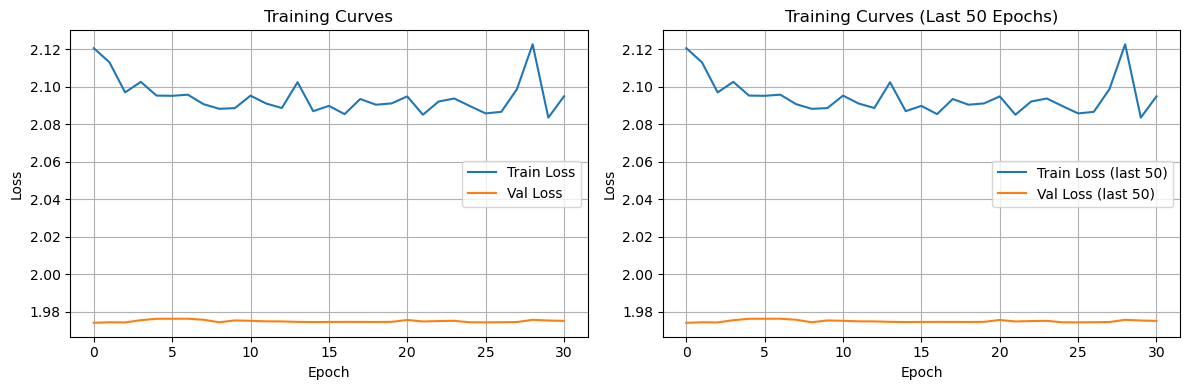

In [91]:
model = ImprovedBTCPricePredictorCNN(input_features=20, sequence_length=3)

model_info(model)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,  # Learning rate
    weight_decay=1e-5,  # L2 regularization
    betas=(0.9, 0.999)  # Adam parameters
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',  # Monitor validation loss (minimize)
    factor=0.5,  # Reduce LR by half when plateauing
    patience=10,  # Wait 10 epochs before reducing LR
    verbose=True,  # Print when LR is reduced
    min_lr=1e-6   # Minimum learning rate
)

model = train_improved_model(model, train_loader, val_loader, epochs=200)

Validation Metrics:
MSE: 15.899771
MAE: 1.977158
R²: -0.000025
RMSE: 3.987452


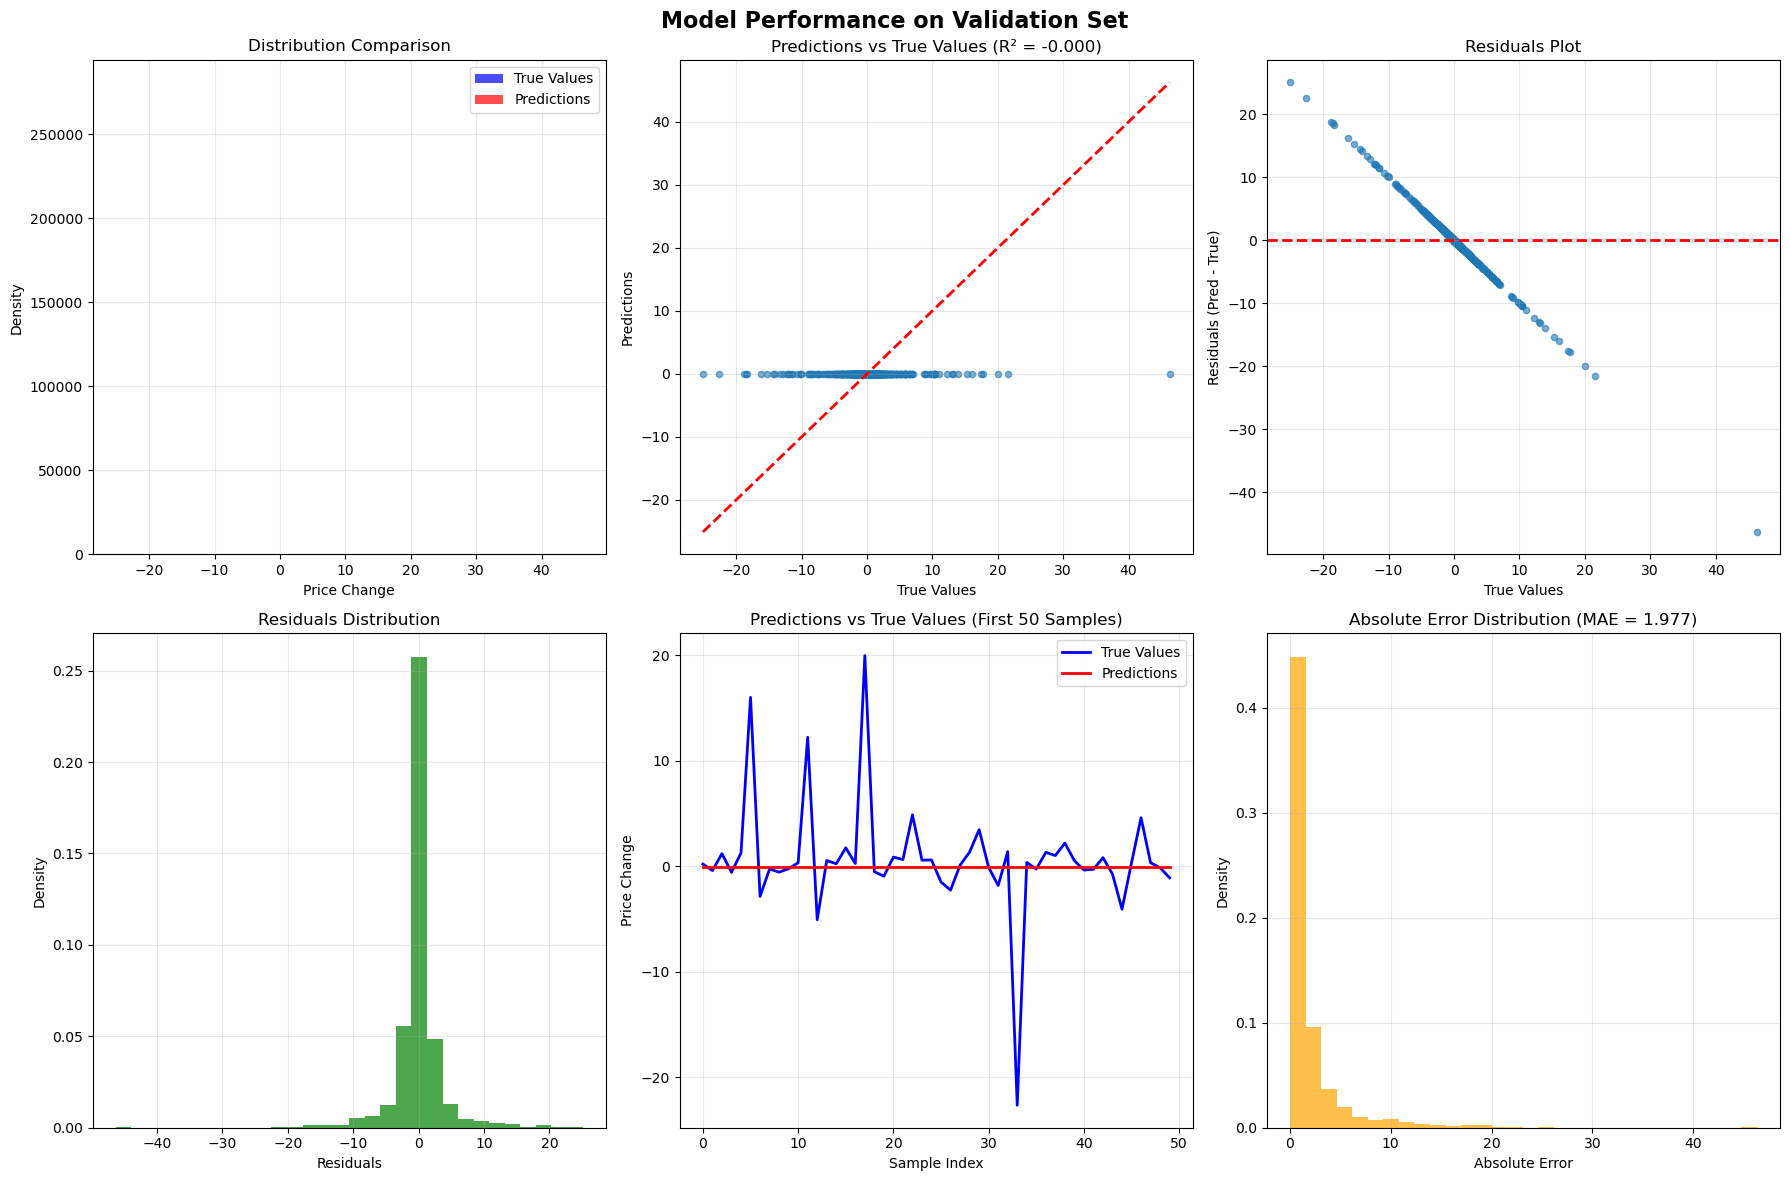


Detailed Statistics:
True values - Mean: -0.006712, Std: 3.987402
Predictions - Mean: -0.026504, Std: 0.000002
Residuals - Mean: -0.019793, Std: 3.987402
Correlation: -0.034513
Outliers (>3σ): 24 out of 891 (2.7%)


In [92]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set model to evaluation mode
model.eval()

# Move model to CPU for inference (since your data is on CPU)
device = torch.device('cpu')
model = model.to(device)

# Collect predictions and true values from validation set
val_predictions = []
val_targets = []

with torch.no_grad():
    for sequences, targets in val_loader:
        # Move data to the same device as model
        sequences = sequences.to(device)
        targets = targets.to(device)
        
        outputs = model(sequences).squeeze()
        val_predictions.extend(outputs.cpu().numpy())
        val_targets.extend(targets.cpu().numpy())

val_predictions = np.array(val_predictions)
val_targets = np.array(val_targets)

# Calculate metrics
mse = mean_squared_error(val_targets, val_predictions)
mae = mean_absolute_error(val_targets, val_predictions)
r2 = r2_score(val_targets, val_predictions)

print(f"Validation Metrics:")
print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"R²: {r2:.6f}")
print(f"RMSE: {np.sqrt(mse):.6f}")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Model Performance on Validation Set', fontsize=16, fontweight='bold')

# 1. Distribution comparison
axes[0, 0].hist(val_targets, bins=30, alpha=0.7, label='True Values', color='blue', density=True)
axes[0, 0].hist(val_predictions, bins=30, alpha=0.7, label='Predictions', color='red', density=True)
axes[0, 0].set_xlabel('Price Change')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Distribution Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Scatter plot
axes[0, 1].scatter(val_targets, val_predictions, alpha=0.6, s=20)
axes[0, 1].plot([val_targets.min(), val_targets.max()], [val_targets.min(), val_targets.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('True Values')
axes[0, 1].set_ylabel('Predictions')
axes[0, 1].set_title(f'Predictions vs True Values (R² = {r2:.3f})')
axes[0, 1].grid(True, alpha=0.3)

# 3. Residuals plot
residuals = val_predictions - val_targets
axes[0, 2].scatter(val_targets, residuals, alpha=0.6, s=20)
axes[0, 2].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 2].set_xlabel('True Values')
axes[0, 2].set_ylabel('Residuals (Pred - True)')
axes[0, 2].set_title('Residuals Plot')
axes[0, 2].grid(True, alpha=0.3)

# 4. Residuals distribution
axes[1, 0].hist(residuals, bins=30, alpha=0.7, color='green', density=True)
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('Residuals Distribution')
axes[1, 0].grid(True, alpha=0.3)

# 5. Time series of predictions vs actual (first 50 samples)
sample_size = min(50, len(val_targets))
axes[1, 1].plot(range(sample_size), val_targets[:sample_size], 'b-', label='True Values', linewidth=2)
axes[1, 1].plot(range(sample_size), val_predictions[:sample_size], 'r-', label='Predictions', linewidth=2)
axes[1, 1].set_xlabel('Sample Index')
axes[1, 1].set_ylabel('Price Change')
axes[1, 1].set_title('Predictions vs True Values (First 50 Samples)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Error distribution
absolute_errors = np.abs(residuals)
axes[1, 2].hist(absolute_errors, bins=30, alpha=0.7, color='orange', density=True)
axes[1, 2].set_xlabel('Absolute Error')
axes[1, 2].set_ylabel('Density')
axes[1, 2].set_title(f'Absolute Error Distribution (MAE = {mae:.3f})')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional statistics
print(f"\nDetailed Statistics:")
print(f"True values - Mean: {val_targets.mean():.6f}, Std: {val_targets.std():.6f}")
print(f"Predictions - Mean: {val_predictions.mean():.6f}, Std: {val_predictions.std():.6f}")
print(f"Residuals - Mean: {residuals.mean():.6f}, Std: {residuals.std():.6f}")
print(f"Correlation: {np.corrcoef(val_targets, val_predictions)[0,1]:.6f}")

# Check for any extreme outliers
outlier_threshold = 3 * np.std(residuals)
outliers = np.abs(residuals) > outlier_threshold
print(f"Outliers (>3σ): {outliers.sum()} out of {len(residuals)} ({outliers.sum()/len(residuals)*100:.1f}%)")